# RT
Load RT data and clean it step by step.

In [53]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [54]:
from pathlib import Path
import pandas as pd


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")


def load_rt_data() -> tuple[pd.DataFrame, Path]:
    project_root = resolve_project_root()
    rt_file = project_root / "data" / "raw" / "Alternative Medien" / "RT_de.xlsx"

    frame = pd.read_excel(rt_file)
    frame["source"] = "RT_de"
    frame["source_file"] = rt_file.name
    return frame, rt_file


df, rt_file = load_rt_data()
df_clean = df.copy()


In [55]:
df_clean = df_clean.drop(columns=["Full_Text"], errors="ignore")
df_clean

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow\n\nDie Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx
...,...,...,...,...,...,...,...,...
12385,2024-11-14,Hauptseite\n/\nSchweiz,Gedemütigt und geschlagen: Was Prostituierte in der Schweiz durchmachen,"Die Realität von Sexarbeiterinnen in der Schweiz bleibt auch heute noch erschreckend: Gewalt, Diskriminierung und sexuelle Übergriffe gehören zum Alltag vie...","Eine aktuelle Studie der Schweizer Organisation ProCoRe verdeutlicht die prekären Umstände, denen diese Frauen ausgesetzt sind.\n\nDie Befragung, die 24 Fra...",https://freedert.online/schweiz/225947-geschlagen-und-gedemuetigt-was-prostituierte/,RT_de,RT_de.xlsx
12386,2024-11-14,Hauptseite\n/\nUkraine-Krieg,Bloomberg: Ukrainer spenden immer weniger für ihre Streitkräfte,"Ukrainische Stiftungen, die die Armee unterstützen, melden starke Rückgänge der Spenden. Angesichts der wirtschaftlichen Schwierigkeiten, Kriegsmüdigkeit un...","Die Bereitschaft der Ukrainer, zur Verteidigung des Landes beizutragen, hat nachgelassen, berichtet die Nachrichtenagentur Bloomberg. Angesichts der Wirtsch...",https://freedert.online/europa/225884-bloomberg-ukrainer-spenden-immer-weniger/,RT_de,RT_de.xlsx
12387,2024-11-14,Hauptseite\n/\nÖsterreich,Österreich: Traditionsmarke Kika/Leiner vor dem Aus,"Ein bitteres Ende für den österreichischen

In [56]:
from IPython.display import display

pd.set_option("display.max_colwidth", 160)

def clean_rt_text_column(frame: pd.DataFrame) -> pd.DataFrame:
    cleaned = frame.copy()
    cleaned["Text"] = (
        cleaned["Text"]
        .astype("string")
        .fillna("")
        .str.replace(r"(?s)\n*\s*Mehr zum Thema.*$", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return cleaned


df_clean = clean_rt_text_column(df_clean)

print(f"Loaded {len(df_clean):,} rows from {rt_file}")


Loaded 12,390 rows from /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/RT_de.xlsx


In [57]:
# compute and display missing values per column for the cleaned dataframe
missing = df_clean.isna().sum().rename("missing_count").to_frame()
missing["missing_pct"] = (missing["missing_count"] / len(df_clean)) * 100
missing = missing.sort_values("missing_count", ascending=False)
missing


,missing_count,missing_pct
Summary,14,0.112994
Date,0,0.000000
Category,0,0.000000
Title,0,0.000000
Text,0,0.000000
URL,0,0.000000
source,0,0.000000
source_file,0,0.000000


In [58]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [59]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="%Y-%m-%d", errors="coerce")
df_clean.head().assign(Date=df_clean["Date"].dt.strftime("%d-%m-%Y"))


,Date,Category,Title,Summary,Text,URL,source,source_file
0,19-01-2026,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,19-01-2026,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,19-01-2026,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,19-01-2026,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,19-01-2026,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [60]:
start_date = pd.Timestamp("2025-08-01")
end_date = pd.Timestamp("2026-02-01")  # exclusive upper bound

df_clean = df_clean[(df_clean["Date"] >= start_date) & (df_clean["Date"] < end_date)].copy()

In [61]:
# now min/max are real dates
print("min:", df_clean["Date"].min())
print("max:", df_clean["Date"].max())


min: 2025-08-01 00:00:00
max: 2026-01-19 00:00:00


In [62]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4570 entries, 0 to 4569
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4570 non-null   datetime64[us]
 1   Category     4570 non-null   str           
 2   Title        4570 non-null   str           
 3   Summary      4567 non-null   str           
 4   Text         4570 non-null   string        
 5   URL          4570 non-null   str           
 6   source       4570 non-null   str           
 7   source_file  4570 non-null   str           
dtypes: datetime64[us](1), str(6), string(1)
memory usage: 285.8 KB


In [63]:
# Text column already created in the dedicated cleaning cell
df_clean["Text"] = df_clean["Text"].astype("string")


Removal of "Mehr zum Thema"

In [64]:
import re
def remove_mehr_zum_thema(text):
    if pd.isna(text):
        return text
    
    # Remove everything from "Mehr zum Thema" until end
    cleaned = re.sub(r"\n*\s*Mehr zum Thema.*$", "", text, flags=re.DOTALL)
    return cleaned.strip()

df_clean["Text"] = df_clean["Text"].apply(remove_mehr_zum_thema)


In [65]:
df_clean.head()

,Date,Category,Title,Summary,Text,URL,source,source_file
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx


In [66]:
#!pip install seaborn


In [67]:
import seaborn as sns
import matplotlib.pyplot as plt


In [68]:
df_clean["article_length_words"] = df_clean["Text"].str.split().str.len()
df_clean["article_length_chars"] = df_clean["Text"].str.len()

df_clean["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)


count    4570.0
mean      582.3
std       410.2
min         0.0
10%       249.9
25%       313.0
50%       421.0
75%       709.8
90%      1208.1
95%      1450.6
99%      1958.0
max      3867.0
Name: article_length_words, dtype: float64

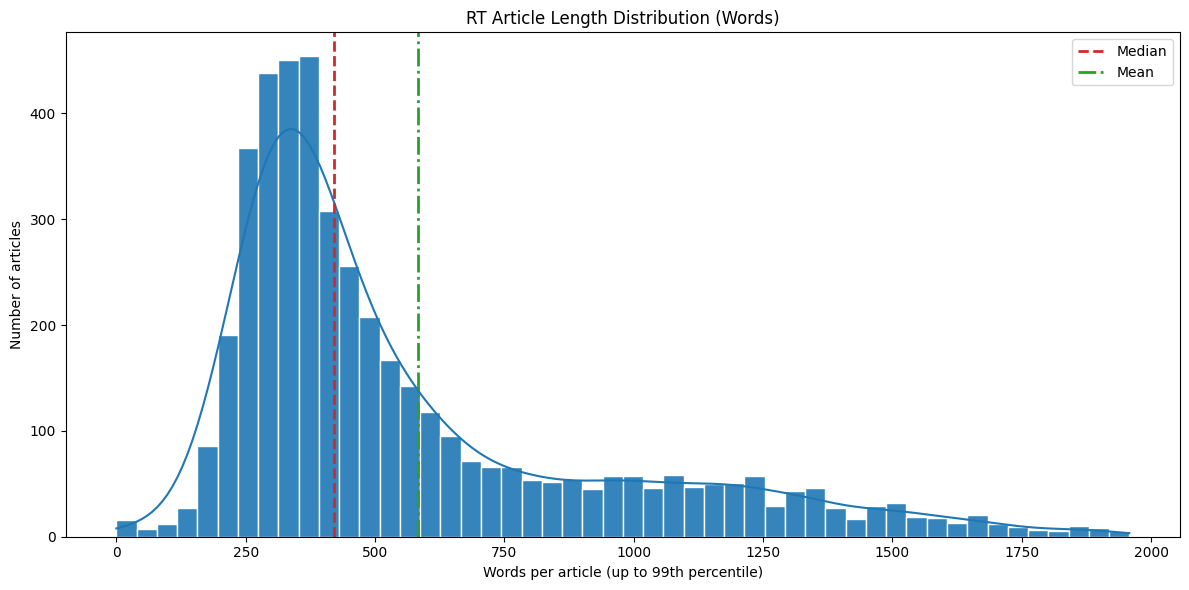

In [69]:
# Plot article length distribution, excluding extreme outliers above the 99th percentile
q99 = df_clean["article_length_words"].quantile(0.99)
length_plot = df_clean[df_clean["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(df_clean["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(df_clean["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("RT Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


In [70]:
# Compute daily article counts and 7-day rolling average
daily_counts = (
    df_clean.set_index("Date")
    .resample("D")
    .size()
    .rename("articles")
    .reset_index()
)
daily_counts["rolling_7d"] = daily_counts["articles"].rolling(7, min_periods=1).mean()

daily_counts.head()


,Date,articles,rolling_7d
0,2025-08-01,15,15.000000
1,2025-08-02,28,21.500000
2,2025-08-03,24,22.333333
3,2025-08-04,26,23.250000
4,2025-08-05,32,25.000000


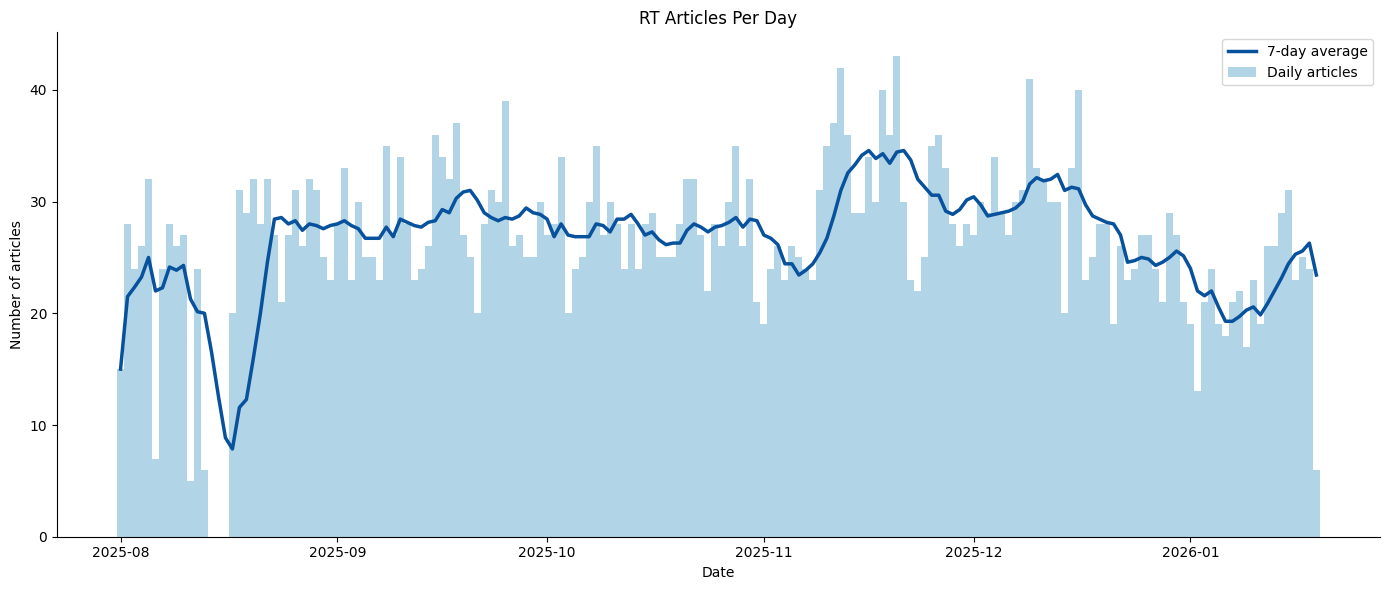

In [71]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(
    daily_counts["Date"],
    daily_counts["articles"],
    color="#9ecae1",
    alpha=0.8,
    width=1.0,
    label="Daily articles",
)
ax.plot(
    daily_counts["Date"],
    daily_counts["rolling_7d"],
    color="#08519c",
    linewidth=2.5,
    label="7-day average",
)

ax.set_title("RT Articles Per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Number of articles")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


In [72]:
df_clean['Date'].max()

Timestamp('2026-01-19 00:00:00')

Duplicates

In [73]:
# Columns to check for duplicate records
dup_cols = ["Title"]


# Find duplicates (all rows that belong to duplicate groups)
dup_mask = df_clean.duplicated(subset=dup_cols, keep=False)
dups = df_clean.loc[dup_mask].sort_values(dup_cols)

print(f"Number of duplicate rows (across {dup_cols}): {len(dups)}")

Number of duplicate rows (across ['Title']): 2


In [74]:
# remove duplicates if either Title OR Inhalt is duplicated
dup_title = df_clean.duplicated(subset=["Title"], keep="first")
dup_text = df_clean.duplicated(subset=["Text"], keep="first")
dup_any = dup_title | dup_text

dups = df_clean.loc[dup_any].copy()      # removed duplicate rows
df_clean = df_clean.loc[~dup_any].copy() # keep only unique rows

print(f"Removed duplicates: {dup_any.sum()}")
print(f"Remaining rows: {len(df_clean)}")

df_clean.head()

Removed duplicates: 10
Remaining rows: 4560


,Date,Category,Title,Summary,Text,URL,source,source_file,article_length_words,article_length_chars
0,2026-01-19,Hauptseite\n/\nInternational,"Trump: Dänemark kann ""russische Bedrohung"" in Grönland nicht beseitigen","Die Nordatlantikallianz habe Dänemark 20 Jahre lang gebeten, die ""russische Bedrohung"" für Grönland zu beseitigen, aber Kopenhagen habe diese Aufgabe nicht ...","Dänemark sei seit 20 Jahren nicht in der Lage, die ""russische Bedrohung"" in der Region Grönland zu beseitigen, behauptete US-Präsident Donald Trump. Auf sei...",https://freedert.online/international/267662-trump-wirft-daenemark-vor-russische/,RT_de,RT_de.xlsx,280,1979
1,2026-01-19,Hauptseite\n/\nInternational,Mindestens 39 Tote bei schwerem Zugunglück in Spanien,"Bei einem schweren Zugunglück nahe Córdoba entgleisten und kollidierten zwei Hochgeschwindigkeitszüge. Mindestens 39 Menschen kamen ums Leben, rund 70 wurde...","Bei einem schweren Zugunglück im Süden Spaniens verloren mindestens 39 Menschen ihr Leben. Rund 70 weitere Passagiere wurden verletzt, mehrere von ihnen sch...",https://freedert.online/europa/267660-mindestens-39-tote-bei-schwerem/,RT_de,RT_de.xlsx,423,3091
2,2026-01-19,Hauptseite\n/\nNahost-Konflikt,Syriens Machthaber al-Scharaa verschiebt wegen Militäroperationen seinen Termin in Berlin,Der für Anfang der Woche angekündigte Besuch des syrischen Übergangspräsidenten Ahmed al-Scharaa im Berliner Kanzleramt ist seitens Damaskus abgesagt worden...,Bundeskanzler Friedrich Merz wird am morgigen Dienstag nicht den amtierenden syrischen Präsidenten Ahmed al-Scharaa im Berliner Bundeskanzleramt empfangen k...,https://freedert.online/der-nahe-osten/267652-syriens-machthaber-al-scharaa-verschiebt/,RT_de,RT_de.xlsx,418,3211
3,2026-01-19,Hauptseite\n/\nSchweiz,Davos wird zum US-Forum: Zum Auftakt steht das WEF im Zeichen Donald Trumps,"Die größte US-Delegation aller Zeiten, massive Sicherheitsvorkehrungen und konkrete Machtpolitik machen Davos zur Bühne amerikanischer Interessen. Noch vor ...","Das World Economic Forum 2026 steht unter einem offiziellen Leitsatz, doch die tatsächliche Dynamik folgt einer anderen Logik. In Davos dreht sich in diesem...",https://freedert.online/schweiz/267655-davos-wird-zum-us-forum/,RT_de,RT_de.xlsx,329,2534
4,2026-01-19,Hauptseite\n/\nInternational,Welch erbärmliche und prinzipienlose Kreaturen: Warum die Europäer nun Schutz bei Russland suchen,"Europa hat Russlands Rolle verkannt und zahlt nun den Preis, während Washington das Völkerrecht und die UNO offen entwertet. Der geplante ""Friedensrat"" der ...","Von Kirill Strelnikow Die Europäer waren seinerzeit nicht in der Lage zu verstehen und zu akzeptieren, dass die militärische Sonderoperation Russlands in de...",https://freedert.online/meinung/267625-welch-erbaermliche-und-prinzipienlose-kreaturen/,RT_de,RT_de.xlsx,965,6979


Save cleaned table for further analysis

In [75]:
rt_de_clean = df_clean[["Date", "Title", "Text", "source"]].copy()
rt_de_clean.to_csv("rt_de_clean.csv", index=False, encoding="utf-8")

## BERTopic 


In [76]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))


In [77]:
from bertopic_pipeline import run_bertopic_pipeline


In [78]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 4560 entries, 0 to 4569
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  4560 non-null   datetime64[us]
 1   Category              4560 non-null   str           
 2   Title                 4560 non-null   str           
 3   Summary               4557 non-null   str           
 4   Text                  4560 non-null   str           
 5   URL                   4560 non-null   str           
 6   source                4560 non-null   str           
 7   source_file           4560 non-null   str           
 8   article_length_words  4560 non-null   int64         
 9   article_length_chars  4560 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(7)
memory usage: 391.9 KB


In [79]:
from bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)


2 0.9


In [80]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

PROJECT_ROOT = resolve_project_root()
MODULE_ROOT = PROJECT_ROOT / "1a_BERTopic"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)
print("bertopic module root added:", MODULE_ROOT)


cwd: /Users/MattisHaumann/Dev/Thesis/00_Initial EDA
project root added: /Users/MattisHaumann/Dev/Thesis
bertopic module root added: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic


In [81]:
# from BERTopic.bertopic_pipeline import prepare_documents
# from BERTopic.bertopic_config import BERTopicConfig, title_config

# cfg = BERTopicConfig(min_df=5, max_df=0.88)   # or whatever you test
# prep = prepare_documents(df_clean, text_col="Text", config=cfg, id_col="URL")
# n = len(prep)

# print("prepared docs:", n)
# print("min_df:", cfg.min_df, "max_df:", cfg.max_df)
# print("max_df_docs:", int(cfg.max_df * n) if isinstance(cfg.max_df, float) else cfg.max_df)


In [82]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 15:43:56,163 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-19 15:44:16,799 - BERTopic - Embedding - Completed ✓
2026-03-19 15:44:16,799 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 15:44:28,345 - BERTopic - Dimensionality - Completed ✓
2026-03-19 15:44:28,345 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 15:44:28,454 - BERTopic - Cluster - Completed ✓
2026-03-19 15:44:28,478 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 15:44:30,623 - BERTopic - Representation - Completed ✓


In [83]:
topic_info = result["topic_info"]
topic_info.head(20)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1745,-1_nato_putin_kiew_china,"[nato, putin, kiew, china, euro, ukrainische, selenskij, sanktionen, soldaten, europäische]",[Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten Erklärungen und Maßnahmen an. Am gravierendsten ist der Bau ...
1,0,318,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]","[Der neuerliche Angriff der israelischen Armee auf Gaza findet vor einem veränderten Hintergrund statt. Zwar hat US-Außenminister Marco Rubio, der gerade er..."
2,1,269,1_afd_spd_cdu_bsw,"[afd, spd, cdu, bsw, grünen, merz, stimmen, wahl, parteien, demokratie]",[Bei der konstituierenden Ratssitzung im nordrhein-westfälischen Gelsenkirchen am Mittwoch dieser Woche stand nach der Vereidigung von Oberbürgermeisterin A...
3,2,237,2_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
4,3,232,3_putin_selenskij_trumps_wladimir putin,"[putin, selenskij, trumps, wladimir putin, kiew, sanktionen, nato, verhandlungen, konflikts, witkoff]","[US-Präsident Donald Trump hat sich für die Organisation eines dreiseitigen Gipfels mit Wladimir Putin und Wladimir Selenskij ausgesprochen, um die Ukraine-..."
5,4,126,4_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, xi, japan, zölle, beziehungen]","[Der chinesische Präsident Xi Jinping, der wiederholt erklärt hat, dass die Wiedervereinigung mit Taiwan ""unvermeidlich"" sei, bekräftigte diese Ansicht in s..."
6,5,123,5_nato_putin_estland_russen,"[nato, putin, estland, russen, estnischen, finnland, bedrohung, kallas, gegen russland, grenze]","[Von Anton Gentzen Die grüne Bundestagsabgeordnete Sara Nanni, sicherheitspolitische Sprecherin ihrer Fraktion und durch militante antirussische Äußerungen ..."
7,6,108,6_polizei_verletzt_täter_brand,"[polizei, verletzt, täter, brand, jährige, ermittlungen, verletzten, feuerwehr, personen, berliner]",[Für den frühen Samstagabend und den frühen Sonntagmorgen finden sich gleich zwei Polizeimeldungen zu eskalierenden Gewaltsituationen unter Einsatz von Mess...
8,7,100,7_selenskij_nabu_minditsch_ukrainische,"[selenskij, nabu, minditsch, ukrainische, selenskijs, jermak, korruption, kiew, ukrainer, korruptionsskandal]","[Von Andrei Restschikow Die Ukraine hat dem US-Kongress die Situation in einem großen Korruptionsfall im Energiesektor erläutert, in den auch Timur Minditsc..."
9,8,97,8_vermögenswerte_euro_milliarden euro_belgien,"[vermögenswerte, euro, milliarden euro, belgien, euroclear, gelder, eingefrorenen, kommission, kiew, für ukraine]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...


In [84]:
#pip install gensim

In [85]:
import sys
!{sys.executable} -m pip install "scipy<1.13" "gensim==4.3.2"


In [86]:
# pip install gensim
import re
import numpy as np
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel


def get_topic_words(topic_model, top_k=10, include_outlier=False):
    topic_info = topic_model.get_topic_info()
    topic_ids = topic_info["Topic"].tolist()
    if not include_outlier:
        topic_ids = [t for t in topic_ids if t != -1]

    topics = []
    for topic_id in topic_ids:
        terms = topic_model.get_topic(int(topic_id)) or []
        words = [w for w, _ in terms[:top_k]]
        if words:
            topics.append(words)
    return topics


def evaluate_bertopic(docs, topic_model, top_k=10):
    # 1) Topic words
    topics = get_topic_words(topic_model, top_k=top_k, include_outlier=False)
    if not topics:
        return {"coherence_npmi": np.nan, "topic_diversity": np.nan}

    # 2) Tokenize docs for coherence
    texts = [re.findall(r"(?u)\b\w\w+\b", str(doc).lower()) for doc in docs]
    dictionary = Dictionary(texts)

    # Keep only topic words that exist in corpus dictionary
    topics_for_coherence = [[w for w in t if w in dictionary.token2id] for t in topics]
    topics_for_coherence = [t for t in topics_for_coherence if len(t) >= 2]

    if not topics_for_coherence:
        coherence_npmi = np.nan
    else:
        cm = CoherenceModel(
            topics=topics_for_coherence,
            texts=texts,
            dictionary=dictionary,
            coherence="c_npmi",
        )
        coherence_npmi = cm.get_coherence()

    # 3) Topic diversity = unique words / (num_topics * top_k)
    all_words = [w for t in topics for w in t]
    topic_diversity = len(set(all_words)) / (len(topics) * top_k)

    return {
        "coherence_npmi": coherence_npmi,
        "topic_diversity": topic_diversity,
        "num_topics": len(topics),
        "top_k": top_k,
    }


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.09035210522490707,
 'topic_diversity': 0.8710526315789474,
 'num_topics': 38,
 'top_k': 10}

In [87]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=10),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 15:44:53,992 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-19 15:45:13,840 - BERTopic - Embedding - Completed ✓
2026-03-19 15:45:13,840 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 15:45:19,243 - BERTopic - Dimensionality - Completed ✓
2026-03-19 15:45:19,244 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 15:45:19,315 - BERTopic - Cluster - Completed ✓
2026-03-19 15:45:19,318 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 15:45:21,449 - BERTopic - Representation - Completed ✓


In [88]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1969,-1_eu_ukrainischen_afd_nato,"[eu, ukrainischen, afd, nato, deutschen, putin, europäischen, moskau, russlands, ukrainische]",[Der russische Präsident Wladimir Putin hat am 19. Dezember seine jährliche große Fragestunde abgehalten. Die Sendung dauerte fast viereinhalb Stunden. In d...
1,0,318,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
2,1,171,1_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venezolanischen, venezolanische, nicolás, nicolás maduro, caracas, washington]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,123,2_nato_russlands_putin_eu,"[nato, russlands, putin, eu, moskau, estland, russen, estnischen, finnland, europäischen]","[Von Kirill Strelnikow Äußerungen, die Russlands Präsident Wladimir Wladimirowitsch Putin auf der jüngsten Sitzung des Sicherheitsrats des Landes machte, kö..."
4,3,111,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, japan, xi, zölle, takaichi]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
5,4,110,4_selenskij_treffen_putin_präsidenten,"[selenskij, treffen, putin, präsidenten, kiew, trumps, wladimir, us präsident, donald, donald trump]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
6,5,97,5_vermögenswerte_eu_milliarden_milliarden euro,"[vermögenswerte, eu, milliarden, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, geld]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...
7,6,86,6_drohnen_luftraum_polen_nato,"[drohnen, luftraum, polen, nato, drohne, polnischen, flugzeuge, vorfall, eu, ukrainische]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
8,7,66,7_eu_orbán_ungarn_ungarische,"[eu, orbán, ungarn, ungarische, serbien, brüssel, viktor, union, moldawien, beitritt]","[Das informelle EU-Gipfeltreffen, das heute in der dänischen Hauptstadt stattfindet, werde ""gefährlich"" sein, denn ""Europa steuert mit großen Schritten auf ..."
9,8,60,8_euro_deutschen_wirtschaft_deutsche,"[euro, deutschen, wirtschaft, deutsche, industrie, unternehmen, bundesregierung, quartal, milliarden euro, zahlen]",[Die Zahl der Unternehmensinsolvenzen in Deutschland ist 2025 auf den höchsten Stand seit elf Jahren angestiegen. 23.900 Firmenpleiten meldet die Wirtschaft...


In [89]:



# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.07130636599710886,
 'topic_diversity': 0.7533333333333333,
 'num_topics': 75,
 'top_k': 10}

In [90]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 15:45:49,610 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-19 15:46:42,685 - BERTopic - Embedding - Completed ✓
2026-03-19 15:46:42,690 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 15:46:58,385 - BERTopic - Dimensionality - Completed ✓
2026-03-19 15:46:58,390 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 15:46:58,494 - BERTopic - Cluster - Completed ✓
2026-03-19 15:46:58,500 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 15:47:05,224 - BERTopic - Representation - Completed ✓


In [91]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1787,-1_nato_ukrainischen_putin_europäischen,"[nato, ukrainischen, putin, europäischen, kiew, euro, ukrainische, milliarden, selenskij, china]",[Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten Erklärungen und Maßnahmen an. Am gravierendsten ist der Bau ...
1,0,318,0_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, iran, al, israelische, netanjahu, gazastreifen, israels]","[Der neuerliche Angriff der israelischen Armee auf Gaza findet vor einem veränderten Hintergrund statt. Zwar hat US-Außenminister Marco Rubio, der gerade er..."
2,1,269,1_afd_partei_spd_cdu,"[afd, partei, spd, cdu, bsw, grünen, merz, stimmen, wahl, parteien]","[In einer von den Unions- und SPD-Fraktionen beantragten ""Aktuellen Stunde"" mit dem laut Bundestagswebseite wörtlichen Titel ""Auswirkungen des Verhältnisses..."
3,2,171,2_venezuela_maduro_venezuelas_karibik,"[venezuela, maduro, venezuelas, karibik, venezolanischen, venezolanische, nicolás, nicolás maduro, caracas, washington]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
4,3,126,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, xi, japan, zölle, beziehungen]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
5,4,123,4_nato_putin_estland_russen,"[nato, putin, estland, russen, estnischen, europäischen, finnland, bedrohung, kallas, konflikt]","[Von Oleg Issaitschenko Die estnische Regierung hat der NATO vorgeschlagen, Übungen zum Einsatz von Atomwaffen in der Nähe der russischen Grenze durchzuführ..."
6,5,110,5_selenskij_putin_kiew_trumps,"[selenskij, putin, kiew, trumps, us präsident, washington, weißen, nato, konflikt, ukrainischen]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
7,6,100,6_selenskij_nabu_minditsch_ukrainischen,"[selenskij, nabu, minditsch, ukrainischen, selenskijs, ukrainische, jermak, korruption, ukrainer, kiew]","[Von Andrei Restschikow Die Ukraine hat dem US-Kongress die Situation in einem großen Korruptionsfall im Energiesektor erläutert, in den auch Timur Minditsc..."
8,7,97,7_vermögenswerte_milliarden_euro_milliarden euro,"[vermögenswerte, milliarden, euro, milliarden euro, belgien, euroclear, gelder, eingefrorenen, geld, kommission]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...
9,8,86,8_drohnen_luftraum_nato_polen,"[drohnen, luftraum, nato, polen, drohne, polnischen, flugzeuge, vorfall, ukrainische, polnische]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...


In [92]:



# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics


{'coherence_npmi': 0.07254854535043197,
 'topic_diversity': 0.7814814814814814,
 'num_topics': 54,
 'top_k': 10}

In [93]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, hdbscan_min_samples=4),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 15:49:21,420 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-19 15:50:02,699 - BERTopic - Embedding - Completed ✓
2026-03-19 15:50:02,757 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 15:50:31,422 - BERTopic - Dimensionality - Completed ✓
2026-03-19 15:50:31,491 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 15:50:31,694 - BERTopic - Cluster - Completed ✓
2026-03-19 15:50:31,767 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 15:50:38,429 - BERTopic - Representation - Completed ✓


In [94]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1714,-1_ukrainischen_afd_nato_europäischen,"[ukrainischen, afd, nato, europäischen, ukrainische, kiew, selenskij, putin, euro, länder]","[Von Dagmar Henn Teil l Die norwegische Studie ""Europes Choice"" (Europas Wahl) lieferte nach ihrem Erscheinen auf Englisch zahlreiche Schlagzeilen in Deutsc..."
1,0,302,0_putin_selenskij_wladimir_us präsident,"[putin, selenskij, wladimir, us präsident, trumps, wladimir putin, washington, kiew, verhandlungen, beziehungen]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
2,1,208,1_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, gazastreifen, israelische, netanjahu, israels, geiseln, al]","[Der neuerliche Angriff der israelischen Armee auf Gaza findet vor einem veränderten Hintergrund statt. Zwar hat US-Außenminister Marco Rubio, der gerade er..."
3,2,132,2_nato_putin_estland_russen,"[nato, putin, estland, russen, estnischen, finnland, länder, europäischen, bedrohung, konflikt]","[Der russische Präsident Wladimir Putin hielt auf dem renommierten internationalen Experten-Forum ""Waldai"" eine Grundsatzrede zum Zustand der internationale..."
4,3,116,3_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesischen, chinesische, japan, xi, zölle, takaichi]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
5,4,101,4_vermögenswerte_milliarden_milliarden euro_euro,"[vermögenswerte, milliarden, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, geld, kommission]",[Von Achim Detjen Auf dem am Donnerstag beginnenden zweitägigen Gipfel der EU-Staats- und Regierungschefs in Brüssel steht die Finanzierung des Ukraine-Krie...
6,5,85,5_drohnen_luftraum_nato_polen,"[drohnen, luftraum, nato, polen, drohne, polnischen, flughafen, flugzeug, flugzeuge, vorfall]",[Von Boris Dscherelijewski In den vergangenen vier Jahren wurden Russland und die Ukraine zu führenden Mächten im Hinblick auf Kampfeinsatz und Bekämpfung v...
7,6,82,6_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, nicolás, nicolás maduro, caracas, machado, venezolanische, rodríguez]","[Von Dmitri Bawyrin Der venezolanische Präsident Nicolás Maduro bezeichnet die Nobelpreisträgerin María Machado als ""dämonische Hexe"". Er ist zwar selbst ke..."
8,7,75,7_us dollar_dollar_barrel_tonnen,"[us dollar, dollar, barrel, tonnen, millionen tonnen, pro, öl, pro barrel, dollar pro, opec]","[Von Olga Samofalowa Die acht führenden Länder der Organisation erdölexportierender Länder (OPEC) haben beschlossen, ihre Entscheidung beizubehalten, die Öl..."
9,8,70,8_euro_wirtschaft_industrie_bundesregierung,"[euro, wirtschaft, industrie, bundesregierung, quartal, studie, zahlen, milliarden, milliarden euro, zahl]",[Die Zahl der Unternehmensinsolvenzen in Deutschland ist 2025 auf den höchsten Stand seit elf Jahren angestiegen. 23.900 Firmenpleiten meldet die Wirtschaft...


In [95]:


# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.08330559033430013,
 'topic_diversity': 0.7840579710144927,
 'num_topics': 69,
 'top_k': 10}

In [96]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=15, hdbscan_min_samples=3, max_df=0.85),
    id_col="URL",
    source_name="RT_de",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-19 15:51:19,869 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/143 [00:00<?, ?it/s]

2026-03-19 15:52:01,467 - BERTopic - Embedding - Completed ✓
2026-03-19 15:52:01,469 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-19 15:52:07,757 - BERTopic - Dimensionality - Completed ✓
2026-03-19 15:52:07,758 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-19 15:52:07,825 - BERTopic - Cluster - Completed ✓
2026-03-19 15:52:07,827 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-19 15:52:10,374 - BERTopic - Representation - Completed ✓


In [97]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1374,-1_afd_ukrainischen_euro_merz,"[afd, ukrainischen, euro, merz, kiew, ukrainische, china, soldaten, polen, armee]",[Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten Erklärungen und Maßnahmen an. Am gravierendsten ist der Bau ...
1,0,313,0_selenskij_us präsident_trumps_wladimir putin,"[selenskij, us präsident, trumps, wladimir putin, kiew, verhandlungen, beziehungen, alaska, konflikts, gespräche]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
2,1,237,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,212,2_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, gazastreifen, israelische, netanjahu, israels, geiseln, al]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
4,3,159,3_estland_russen_estnischen_finnland,"[estland, russen, estnischen, finnland, bedrohung, grenze, beziehungen, kallas, wladimir putin, polen]",[Von Murad Sadygsade Im Laufe des Jahres 2025 glich Moskaus Kurs in der russischen Nahostpolitik einer systematischen Feinabstimmung bestehender Kanäle. Daz...
5,4,118,4_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, japan, xi, zölle, takaichi]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
6,5,113,5_selenskij_ukrainischen_nabu_minditsch,"[selenskij, ukrainischen, nabu, minditsch, ukrainische, selenskijs, jermak, korruption, kiew, ukrainer]","[Von Andrei Restschikow Die Ukraine hat dem US-Kongress die Situation in einem großen Korruptionsfall im Energiesektor erläutert, in den auch Timur Minditsc..."
7,6,102,6_vermögenswerte_milliarden euro_euro_belgien,"[vermögenswerte, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, geld, kommission, russischer vermögenswerte]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
8,7,89,7_drohnen_luftraum_polen_drohne,"[drohnen, luftraum, polen, drohne, polnischen, flugzeug, vorfall, flughafen, flugzeuge, russische drohnen]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
9,8,88,8_orbán_ungarn_ungarische_brüssel,"[orbán, ungarn, ungarische, brüssel, serbien, viktor, union, viktor orbán, beitritt, budapest]","[Das informelle EU-Gipfeltreffen, das heute in der dänischen Hauptstadt stattfindet, werde ""gefährlich"" sein, denn ""Europa steuert mit großen Schritten auf ..."


In [98]:
# Save topics from the current BERTopic run
topics_out = PROJECT_ROOT / "1a_BERTopic" / "local_outputs" / "rt_topics_current_run.csv"
topics_out.parent.mkdir(parents=True, exist_ok=True)

result["topic_info"].to_csv(topics_out, index=False, encoding="utf-8-sig")
print(f"Saved topic table to: {topics_out}")

Saved topic table to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/local_outputs/rt_topics_current_run.csv


In [99]:
# Example with your BERTopic result dict
# result = run_bertopic_pipeline(...)
metrics = evaluate_bertopic(docs=result["docs"], topic_model=result["topic_model"], top_k=10)
metrics

{'coherence_npmi': 0.06548929223267322,
 'topic_diversity': 0.8123076923076923,
 'num_topics': 65,
 'top_k': 10}

## Selected RT Baseline

By default this section reuses the latest RT BERTopic run already stored in `result` (the one you just inspected/plotted).

Set `RT_BASELINE_SOURCE = "saved_model"` only when you intentionally want to load the saved artifact from `1a_BERTopic/local_outputs/rt_model`.


In [100]:
from pathlib import Path
import pandas as pd
from bertopic_pipeline import prepare_documents
from bertopic_config import BERTopicConfig
from bertopic import BERTopic

# Default: keep using the latest RT BERTopic run already stored in `result`.
# Switch to "saved_model" only if you explicitly want the artifact on disk.
RT_BASELINE_SOURCE = "latest_run"  # "latest_run" | "saved_model"

rt_config = BERTopicConfig(
    hdbscan_min_cluster_size=15,
    hdbscan_min_samples=3,
    max_df=0.85,
    umap_n_neighbors=40,
    umap_min_dist=0.05,
)

MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "1a_BERTopic" / "local_outputs",
    PROJECT_ROOT / "1a_BERTopic" / "outputs",
]

if RT_BASELINE_SOURCE == "latest_run":
    if "result" not in globals():
        raise RuntimeError(
            "No in-memory `result` found. Run the BERTopic fit cell above or switch "
            "RT_BASELINE_SOURCE to 'saved_model'."
        )

    result_rt = {
        **result,
        "docs": list(result["docs"]),
        "topics": list(result["topics"]),
        "topic_info": result["topic_info"].copy(),
        "doc_info": result["doc_info"].copy(),
    }
    rt_model = result_rt["topic_model"]
    docs_rt_loaded = list(result_rt["docs"])
    topics_rt_loaded = list(result_rt["topics"])
    topic_info_rt_loaded = result_rt["topic_info"].copy()
    doc_info_rt_loaded = result_rt["doc_info"].copy()
    print("Using the latest in-memory RT BERTopic run from `result` as the downstream baseline.")
elif RT_BASELINE_SOURCE == "saved_model":
    rt_model_path = next(
        (candidate / "rt_model" for candidate in MODEL_DIR_CANDIDATES if (candidate / "rt_model").exists()),
        None,
    )
    if rt_model_path is None:
        raise FileNotFoundError(
            "Could not find saved rt_model in: " + ", ".join(str(path) for path in MODEL_DIR_CANDIDATES)
        )
    rt_model = BERTopic.load(rt_model_path)

    prepared_rt = prepare_documents(
        df_clean,
        text_col="Text",
        config=rt_config,
        id_col="URL",
        source_name="RT_de",
    )
    docs_rt_loaded = prepared_rt["document"].tolist()

    topics_attr = list(getattr(rt_model, "topics_", []) or [])
    if len(topics_attr) == len(docs_rt_loaded):
        topics_rt_loaded = topics_attr
    else:
        topics_rt_loaded, _ = rt_model.transform(docs_rt_loaded)
        topics_rt_loaded = list(topics_rt_loaded)
        print(
            "Warning: loaded model topics_ length did not match prepared docs; "
            "used transform(...) assignments."
        )

    rt_model.topics_ = list(topics_rt_loaded)
    if hasattr(rt_model, "probabilities_"):
        rt_model.probabilities_ = None

    topic_info_rt_loaded = rt_model.get_topic_info()

    try:
        doc_info_rt_loaded = rt_model.get_document_info(docs_rt_loaded)
    except Exception as exc:
        topic_name_map = dict(zip(topic_info_rt_loaded["Topic"], topic_info_rt_loaded["Name"]))
        doc_info_rt_loaded = pd.DataFrame({
            "Document": docs_rt_loaded,
            "Topic": topics_rt_loaded,
        })
        doc_info_rt_loaded["Name"] = doc_info_rt_loaded["Topic"].map(topic_name_map)
        print(f"Warning: get_document_info fallback used ({exc}).")

    doc_info_rt_loaded = pd.concat(
        [
            prepared_rt[["original_index", "document_id", "source_name"]].reset_index(drop=True),
            doc_info_rt_loaded.reset_index(drop=True),
        ],
        axis=1,
    )

    result_rt = {
        "config": rt_config,
        "prepared_documents": prepared_rt,
        "docs": docs_rt_loaded,
        "topic_model": rt_model,
        "topics": list(topics_rt_loaded),
        "probabilities": None,
        "topic_info": topic_info_rt_loaded,
        "doc_info": doc_info_rt_loaded,
    }
    print(f"Loaded RT model from: {rt_model_path}")
else:
    raise ValueError("RT_BASELINE_SOURCE must be 'latest_run' or 'saved_model'.")

# Keep the model assignments aligned with the selected baseline docs.
rt_model.topics_ = list(topics_rt_loaded)
result_rt["topic_model"] = rt_model
result_rt["docs"] = list(docs_rt_loaded)
result_rt["topics"] = list(topics_rt_loaded)
result_rt["topic_info"] = topic_info_rt_loaded.copy()
result_rt["doc_info"] = doc_info_rt_loaded.copy()

baseline_outlier_row = result_rt["topic_info"].loc[
    result_rt["topic_info"]["Topic"] == -1,
    ["Topic", "Count", "Name"],
].copy()
display(baseline_outlier_row)


Using the latest in-memory RT BERTopic run from `result` as the downstream baseline.


,Topic,Count,Name
0,-1,1374,-1_afd_ukrainischen_euro_merz


In [101]:
topic_info_rt = result_rt["topic_info"]
topic_info_rt.head(30)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1374,-1_afd_ukrainischen_euro_merz,"[afd, ukrainischen, euro, merz, kiew, ukrainische, china, soldaten, polen, armee]",[Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten Erklärungen und Maßnahmen an. Am gravierendsten ist der Bau ...
1,0,313,0_selenskij_us präsident_trumps_wladimir putin,"[selenskij, us präsident, trumps, wladimir putin, kiew, verhandlungen, beziehungen, alaska, konflikts, gespräche]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
2,1,237,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás maduro, nicolás, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,212,2_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, gazastreifen, israelische, netanjahu, israels, geiseln, al]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
4,3,159,3_estland_russen_estnischen_finnland,"[estland, russen, estnischen, finnland, bedrohung, grenze, beziehungen, kallas, wladimir putin, polen]",[Von Murad Sadygsade Im Laufe des Jahres 2025 glich Moskaus Kurs in der russischen Nahostpolitik einer systematischen Feinabstimmung bestehender Kanäle. Daz...
5,4,118,4_china_taiwan_peking_chinas,"[china, taiwan, peking, chinas, chinesische, chinesischen, japan, xi, zölle, takaichi]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
6,5,113,5_selenskij_ukrainischen_nabu_minditsch,"[selenskij, ukrainischen, nabu, minditsch, ukrainische, selenskijs, jermak, korruption, kiew, ukrainer]","[Von Andrei Restschikow Die Ukraine hat dem US-Kongress die Situation in einem großen Korruptionsfall im Energiesektor erläutert, in den auch Timur Minditsc..."
7,6,102,6_vermögenswerte_milliarden euro_euro_belgien,"[vermögenswerte, milliarden euro, euro, belgien, euroclear, gelder, eingefrorenen, geld, kommission, russischer vermögenswerte]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
8,7,89,7_drohnen_luftraum_polen_drohne,"[drohnen, luftraum, polen, drohne, polnischen, flugzeug, vorfall, flughafen, flugzeuge, russische drohnen]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
9,8,88,8_orbán_ungarn_ungarische_brüssel,"[orbán, ungarn, ungarische, brüssel, serbien, viktor, union, viktor orbán, beitritt, budapest]","[Das informelle EU-Gipfeltreffen, das heute in der dänischen Hauptstadt stattfindet, werde ""gefährlich"" sein, denn ""Europa steuert mit großen Schritten auf ..."


In [102]:
# Safety switch: save the currently selected baseline only if you explicitly enable it.
SAVE_BASELINE_RT_MODEL = False

rt_model = result_rt["topic_model"]
rt_model_path = PROJECT_ROOT / "1a_BERTopic" / "local_outputs" / "rt_model"
rt_model_path.parent.mkdir(parents=True, exist_ok=True)

if SAVE_BASELINE_RT_MODEL:
    rt_model.save(
        rt_model_path,
        serialization="safetensors",   # more robust than pickle
        save_ctfidf=True,
        save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    )
    print(f"Saved baseline RT model to: {rt_model_path}")
else:
    print(f"Skipped baseline save (SAVE_BASELINE_RT_MODEL={SAVE_BASELINE_RT_MODEL}).")


Skipped baseline save (SAVE_BASELINE_RT_MODEL=False).


### Outlier Reduction (focused section)

This section starts from the selected RT topic model (`result_rt`) from the baseline section above and keeps the reduction workflow compact.

> **Final workflow to use downstream:** `strategy="c-tf-idf"` with `threshold=0.10`.


In [103]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_rt).
base_result = result_rt
topic_model_base = base_result["topic_model"]
docs_rt = list(base_result["docs"])
topics_rt = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_rt if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_rt,
    topics_rt,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_rt,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_base.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_rt_reduced = dict(base_result)
result_rt_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_rt_reduced["topic_model"] = topic_model_ctfidf_threshold
result_rt_reduced["topic_info"] = topic_info_ctfidf_threshold
result_rt_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_rt_reduced["doc_info"] = doc_info_reduced
result_rt_reduced["display_topic_map"] = display_topic_map
result_rt_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_rt) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)

display(
    base_result["topic_info"].loc[
        base_result["topic_info"]["Topic"] == -1,
        ["Topic", "Count", "Name"],
    ].reset_index(drop=True)
)
display(
    topic_info_ctfidf_threshold.loc[
        topic_info_ctfidf_threshold["Topic"] == -1,
        ["Topic", "Count", "Name"],
    ].reset_index(drop=True)
)
display(topic_info_ctfidf_threshold.head(20))


2026-03-19 15:53:03,670 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,1374,65
1,ctfidf_threshold_0.10,508,65


,Topic,Count,Name
0,-1,1374,-1_afd_ukrainischen_euro_merz


,Topic,Count,Name
0,-1,508,-1_soldaten_russen_bundesregierung_afd


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_soldaten_russen_bundesregierung_afd,-1,508,-1_soldaten_russen_bundesregierung_afd,"[soldaten, russen, bundesregierung, afd, afghanen, bundeswehr, mitarbeiter, rheinmetall, visa, berliner]",[Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten Erklärungen und Maßnahmen an. Am gravierendsten ist der Bau ...
1,0,1,Topic 1 — selenskij_kiew_trumps_wladimir putin,selenskij_kiew_trumps_wladimir putin,0,377,0_selenskij_kiew_trumps_wladimir putin,"[selenskij, kiew, trumps, wladimir putin, verhandlungen, alaska, konflikts, gespräche, präsident donald, russischen präsidenten]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
2,1,2,Topic 2 — venezuela_maduro_venezuelas_venezolanischen,venezuela_maduro_venezuelas_venezolanischen,1,244,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,3,Topic 3 — israel_gaza_hamas_israelischen,israel_gaza_hamas_israelischen,2,230,2_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, gazastreifen, israelische, israels, netanjahu, geiseln, al]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
4,3,4,Topic 4 — kallas_russen_estland_grenze,kallas_russen_estland_grenze,3,226,3_kallas_russen_estland_grenze,"[kallas, russen, estland, grenze, weißrussland, finnland, estnischen, polen, europäische, litauen]",[Von Murad Sadygsade Im Laufe des Jahres 2025 glich Moskaus Kurs in der russischen Nahostpolitik einer systematischen Feinabstimmung bestehender Kanäle. Daz...
5,4,6,Topic 6 — peking_taiwan_chinas_chinesischen,peking_taiwan_chinas_chinesischen,4,148,4_peking_taiwan_chinas_chinesischen,"[peking, taiwan, chinas, chinesischen, chinesische, japan, xi, takaichi, japanischen, zölle]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
6,5,5,Topic 5 — selenskij_ukrainische_nabu_minditsch,selenskij_ukrainische_nabu_minditsch,5,149,5_selenskij_ukrainische_nabu_minditsch,"[selenskij, ukrainische, nabu, minditsch, selenskijs, kiew, korruption, jermak, ukrainer, kolomoiski]","[Von Andrei Restschikow Die Ukraine hat dem US-Kongress die Situation in einem großen Korruptionsfall im Energiesektor erläutert, in den auch Timur Minditsc..."
7,6,7,Topic 7 — vermögenswerte_milliarden euro_belgien_euroclear,vermögenswerte_milliarden euro_belgien_euroclear,6,128,6_vermögenswerte_milliarden euro_belgien_euroclear,"[vermögenswerte, milliarden euro, belgien, euroclear, eingefrorenen, gelder, kommission, kiew, de wever, wever]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
8,7,8,Topic 8 — drohnen_polen_luftraum_polnischen,drohnen_polen_luftraum_polnischen,7,121,7_drohnen_polen_luftraum_polnischen,"[drohnen, polen, luftraum, polnischen, drohne, flugzeuge, vorfall, polnische, flugzeug, estland]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
9,8,9,Topic 9 — orbán_ungarn_ungarische_brüssel,orbán_ungarn_ungarische_brüssel,8,109,8_orbán_ungarn_ungarische_brüssel,"[orbán, ungarn, ungarische, brüssel, viktor, budapest, europäische, serbien, viktor orbán, druschba]","[Das informelle EU-Gipfeltreffen, das heute in der dänischen Hauptstad

In [104]:
from pathlib import Path
import shutil

# Keep a reusable reduced result dict in notebook memory and make it the current RT result.
result_rt = result_rt_reduced

save_dir = PROJECT_ROOT / "1a_BERTopic" / "local_outputs" / "rt_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved final reduced model to: {save_dir}")


Saved final reduced model to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/local_outputs/rt_model


In [105]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_soldaten_russen_bundesregierung_afd,-1,508,-1_soldaten_russen_bundesregierung_afd,"[soldaten, russen, bundesregierung, afd, afghanen, bundeswehr, mitarbeiter, rheinmetall, visa, berliner]",[Von Wadim Truchatschjow Zieht Europa gegen Russland in den Krieg? Schauen wir uns die jüngsten Erklärungen und Maßnahmen an. Am gravierendsten ist der Bau ...
1,0,1,Topic 1 — selenskij_kiew_trumps_wladimir putin,selenskij_kiew_trumps_wladimir putin,0,377,0_selenskij_kiew_trumps_wladimir putin,"[selenskij, kiew, trumps, wladimir putin, verhandlungen, alaska, konflikts, gespräche, präsident donald, russischen präsidenten]","[Von Oleg Issaitschenko Donald Trump erklärte, dass er das Treffen mit Wladimir Putin in Budapest abgesagt habe. Trump begründete seine Entscheidung nach ei..."
2,1,2,Topic 2 — venezuela_maduro_venezuelas_venezolanischen,venezuela_maduro_venezuelas_venezolanischen,1,244,1_venezuela_maduro_venezuelas_venezolanischen,"[venezuela, maduro, venezuelas, venezolanischen, karibik, venezolanische, caracas, nicolás, nicolás maduro, drogen]",[Präsident Trump hat laut US-Beamten die Bemühungen um eine diplomatische Einigung mit Venezuela abgebrochen. Damit hat er sich den Weg für eine mögliche mi...
3,2,3,Topic 3 — israel_gaza_hamas_israelischen,israel_gaza_hamas_israelischen,2,230,2_israel_gaza_hamas_israelischen,"[israel, gaza, hamas, israelischen, gazastreifen, israelische, israels, netanjahu, geiseln, al]","[Das israelische Militär hat am Sonntag einen Angriff auf Gaza gestartet, wie israelische Medien und Einwohner berichten. Damit schwinden die Hoffnungen, da..."
4,3,4,Topic 4 — kallas_russen_estland_grenze,kallas_russen_estland_grenze,3,226,3_kallas_russen_estland_grenze,"[kallas, russen, estland, grenze, weißrussland, finnland, estnischen, polen, europäische, litauen]",[Von Murad Sadygsade Im Laufe des Jahres 2025 glich Moskaus Kurs in der russischen Nahostpolitik einer systematischen Feinabstimmung bestehender Kanäle. Daz...
5,4,6,Topic 6 — peking_taiwan_chinas_chinesischen,peking_taiwan_chinas_chinesischen,4,148,4_peking_taiwan_chinas_chinesischen,"[peking, taiwan, chinas, chinesischen, chinesische, japan, xi, takaichi, japanischen, zölle]",[Von Dmitri Bawyrin Die Armee der Volksrepublik China hat bereits mehrfach das Regierungsviertel der taiwanesischen Hauptstadt Taipeh gestürmt und die Kontr...
6,5,5,Topic 5 — selenskij_ukrainische_nabu_minditsch,selenskij_ukrainische_nabu_minditsch,5,149,5_selenskij_ukrainische_nabu_minditsch,"[selenskij, ukrainische, nabu, minditsch, selenskijs, kiew, korruption, jermak, ukrainer, kolomoiski]","[Von Andrei Restschikow Die Ukraine hat dem US-Kongress die Situation in einem großen Korruptionsfall im Energiesektor erläutert, in den auch Timur Minditsc..."
7,6,7,Topic 7 — vermögenswerte_milliarden euro_belgien_euroclear,vermögenswerte_milliarden euro_belgien_euroclear,6,128,6_vermögenswerte_milliarden euro_belgien_euroclear,"[vermögenswerte, milliarden euro, belgien, euroclear, eingefrorenen, gelder, kommission, kiew, de wever, wever]","[Laut Plänen der EU-Kommission soll Deutschland zum größten Garantiegeber eines sogenannten ""Reparationskredits"" für die Ukraine werden. Dieser soll über ei..."
8,7,8,Topic 8 — drohnen_polen_luftraum_polnischen,drohnen_polen_luftraum_polnischen,7,121,7_drohnen_polen_luftraum_polnischen,"[drohnen, polen, luftraum, polnischen, drohne, flugzeuge, vorfall, polnische, flugzeug, estland]",[Nach Angaben des polnischen Ministerpräsidenten Donald Tusk waren in der Nacht mindestens drei russische Drohnen von NATO- und polnischen Flugzeugen im pol...
9,8,9,Topic 9 — orbán_ungarn_ungarische_brüssel,orbán_ungarn_ungarische_brüssel,8,109,8_orbán_ungarn_ungarische_brüssel,"[orbán, ungarn, ungarische, brüssel, viktor, budapest, europäische, serbien, viktor orbán, druschba]","[Das informelle EU-Gipfeltreffen, das heute in der dänischen Hauptstad

### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


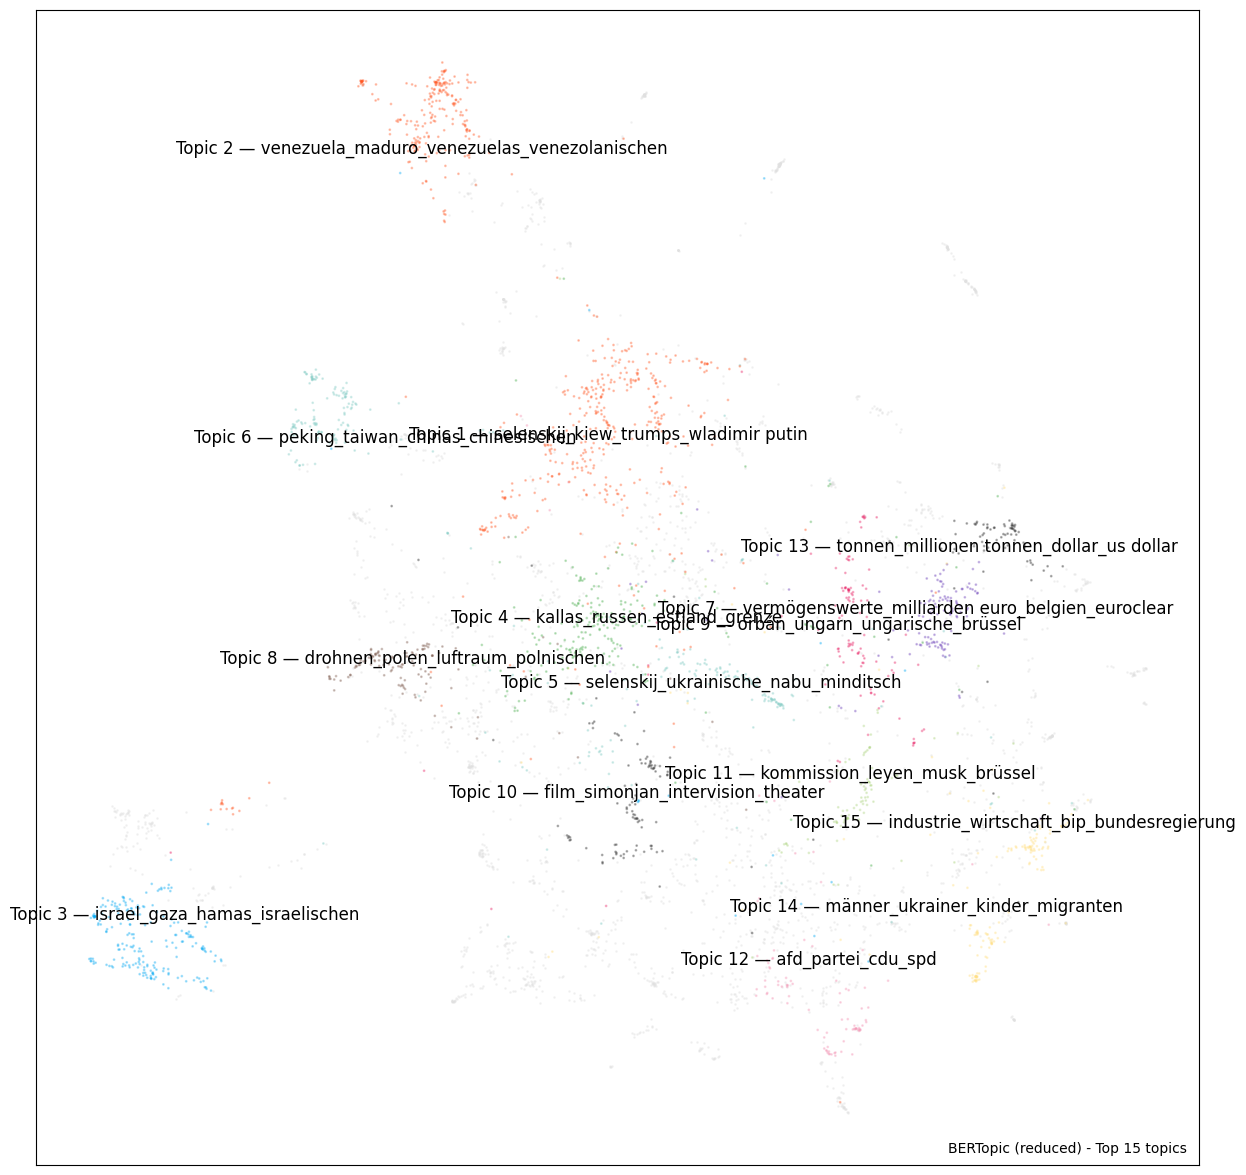

In [106]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()


## Topics Over Time

Uses `result_rt_reduced` if you have already run the outlier-reduction cell; otherwise it falls back to the selected baseline `result_rt`.


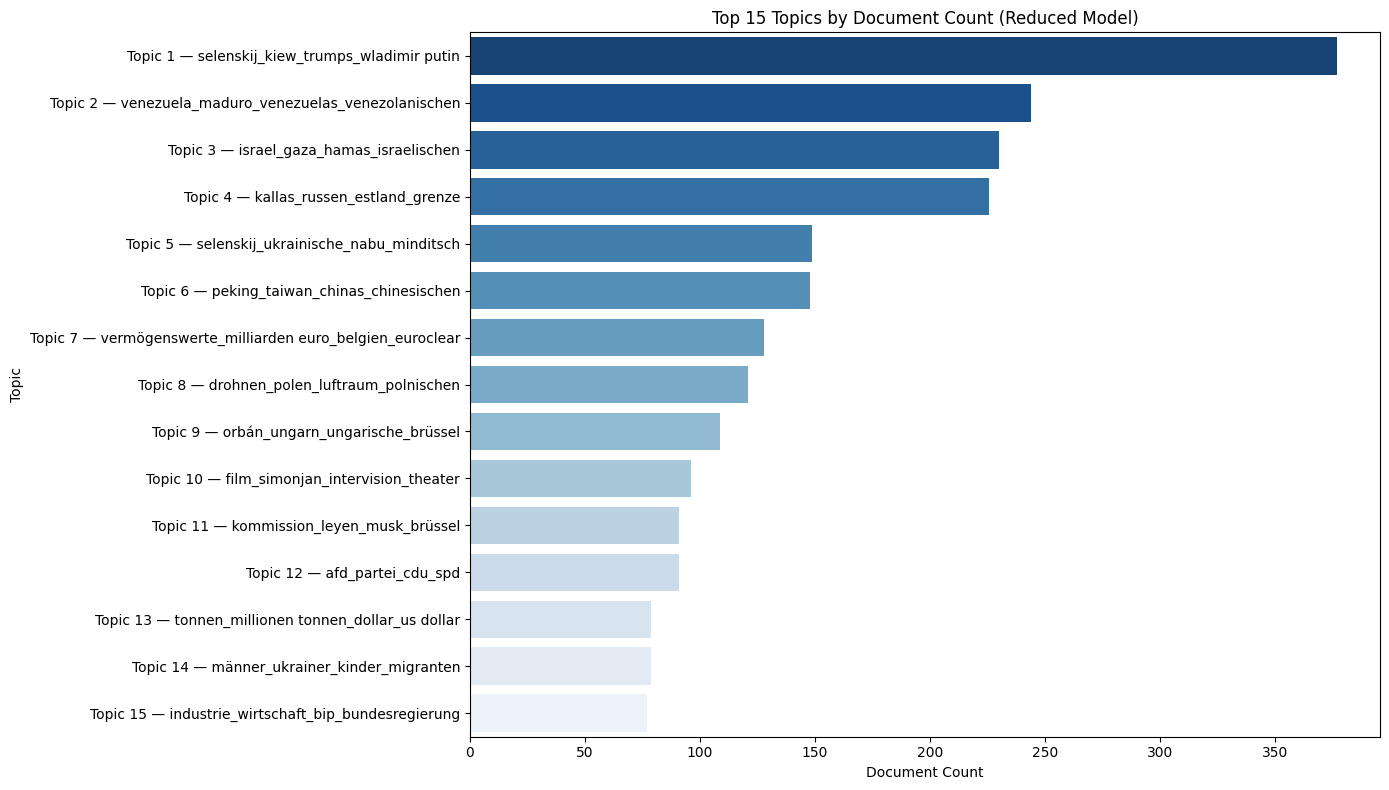

In [107]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Re-run this cell after outlier reduction to visualize the final reduced model with unified topic numbering.
run_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt
topic_info_run = run_result["topic_info"].copy()

if "DisplayTopic" not in topic_info_run.columns:
    topic_info_run["OriginalTopic"] = topic_info_run["Topic"]
    topic_info_run["TopicNameClean"] = topic_info_run["Name"].str.replace(r"^\d+_", "", regex=True)
    ranked_topics = (
        topic_info_run.loc[topic_info_run["Topic"] != -1, ["Topic", "Count"]]
        .sort_values(["Count", "Topic"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
    display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))
    topic_info_run["DisplayTopic"] = topic_info_run["Topic"].map(display_topic_map).astype("Int64")
    topic_info_run["DisplayLabel"] = topic_info_run.apply(
        lambda row: "Outliers"
        if row["Topic"] == -1
        else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
        axis=1,
    )

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()


6it [00:14,  2.38s/it]


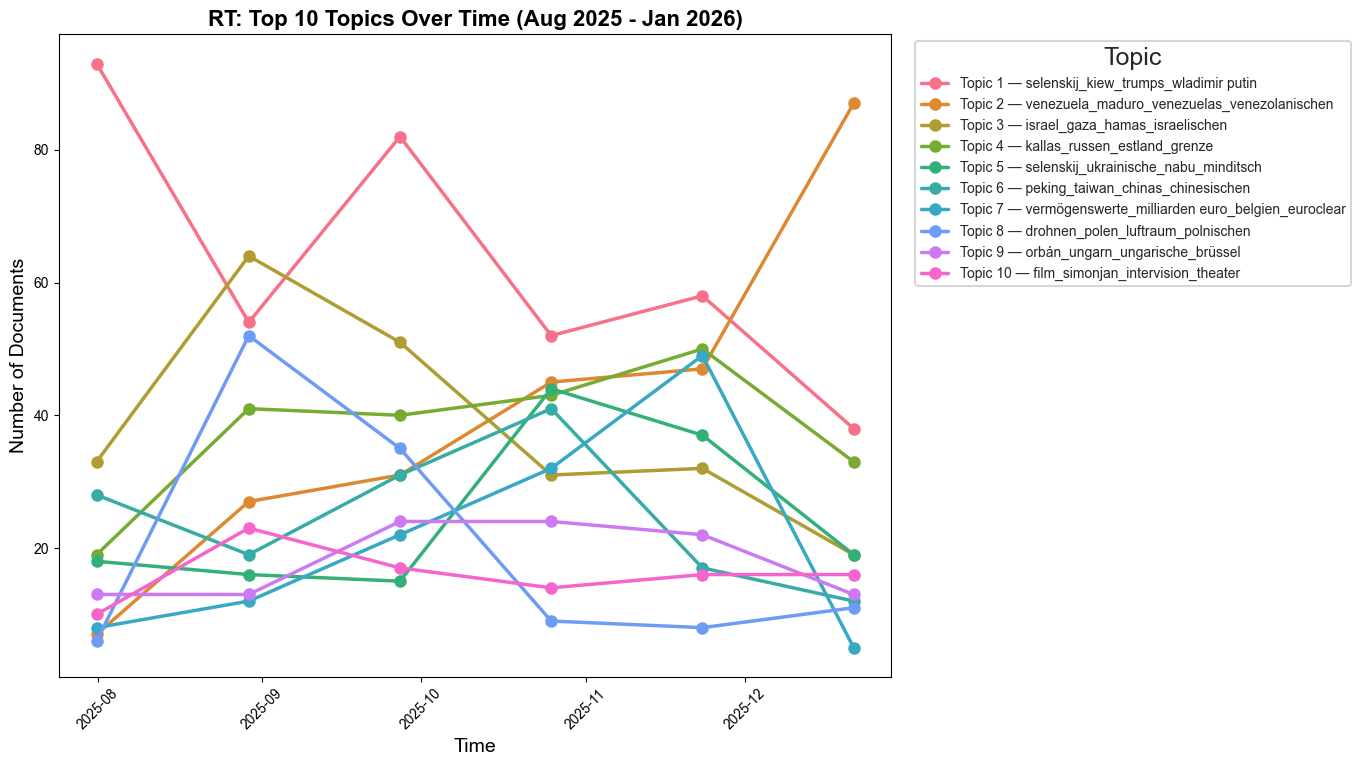

In [108]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_rt_reduced`.
topic_time_result = result_rt_reduced if "result_rt_reduced" in globals() else result_rt

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("RT: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
